# 01 — Parse quality, coverage, and new v1/v2 prompt audit

This notebook checks whether the raw model responses are analysis-ready after the full rerun with both v1 and v2 prompts.

It now includes:
- five-prompt manifest support: naïve, v1 direct, v1 structured, v2 direct abstention, v2 structured abstention;
- parse quality by provider, model, prompt, and prompt generation;
- parse-error inspection;
- coverage checks against the expected grid size.

This notebook should be run before substantive analysis. If a prompt or provider has a high parse-error rate, the accuracy analyses must be interpreted as a mixture of semantic performance and output-format reliability.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run these notebooks from the project notebooks/ directory.
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = DATA_DIR / "outputs"

RAW_PATH = OUTPUTS_DIR / "raw_responses.jsonl"
PARSED_PATH = OUTPUTS_DIR / "parsed_responses.jsonl"
GOLD_PATH = DATA_DIR / "gold" / "sentences_v1.jsonl"
COST_PATH = OUTPUTS_DIR / "cost_log.jsonl"

def read_jsonl(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if line.strip():
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Invalid JSON in {path} at line {line_no}: {exc}") from exc
    return pd.DataFrame(records)

def safe_read_jsonl(path: Path) -> pd.DataFrame:
    return read_jsonl(path) if path.exists() else pd.DataFrame()

def clean_label(value):
    if pd.isna(value):
        return None
    return str(value).strip()

def norm_prompt_generation(prompt_id):
    if pd.isna(prompt_id):
        return "unknown"
    prompt_id = str(prompt_id)
    if "_v2_" in prompt_id or prompt_id.endswith("_v2"):
        return "v2_abstention"
    if "_v1" in prompt_id:
        return "v1"
    return "unknown"

def safe_accuracy(df: pd.DataFrame, pred_col: str, gold_col: str):
    if df.empty or pred_col not in df.columns or gold_col not in df.columns:
        return None
    sub = df[df[pred_col].notna() & df[gold_col].notna()].copy()
    if sub.empty:
        return None
    return float((sub[pred_col].astype(str) == sub[gold_col].astype(str)).mean())

def safe_rate(series):
    if series is None or len(series) == 0:
        return None
    return float(pd.Series(series).mean())

def pct(x, digits=1):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "NA"
    return f"{100*x:.{digits}f}%"

def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "prompt_id" in out.columns:
        out["prompt_generation"] = out["prompt_id"].map(norm_prompt_generation)
        out["uses_abstention_gate"] = out["prompt_id"].astype(str).str.contains("abstention", case=False, na=False)
    else:
        out["prompt_generation"] = "unknown"
        out["uses_abstention_gate"] = False

    if "sentence_type" in out.columns:
        out["gold_schema_present"] = np.where(out["sentence_type"].eq("control_weak_schema"), "no", "yes")
    else:
        out["gold_schema_present"] = np.nan

    if "main_image_schema" in out.columns:
        out["predicted_schema_present_from_schema"] = np.where(out["main_image_schema"].eq("NONE"), "no", "yes")
    else:
        out["predicted_schema_present_from_schema"] = np.nan

    if "schema_present" not in out.columns:
        out["schema_present"] = out["predicted_schema_present_from_schema"]

    if "literal_or_metaphorical" not in out.columns:
        out["literal_or_metaphorical"] = np.nan

    if "expected_literal_or_metaphorical" not in out.columns:
        out["expected_literal_or_metaphorical"] = np.nan

    if "main_image_schema" not in out.columns:
        out["main_image_schema"] = np.nan

    if "expected_schema_primary" not in out.columns:
        out["expected_schema_primary"] = np.nan

    out["is_control"] = out["sentence_type"].eq("control_weak_schema") if "sentence_type" in out.columns else False
    out["is_structured_json"] = out["parse_status"].eq("parsed") if "parse_status" in out.columns else False
    out["control_correct"] = out["is_control"] & out["literal_or_metaphorical"].eq("control") & out["main_image_schema"].eq("NONE")
    out["control_false_positive_schema"] = out["is_control"] & out["main_image_schema"].notna() & ~out["main_image_schema"].eq("NONE")
    out["schema_present_correct"] = out["schema_present"].eq(out["gold_schema_present"])
    out["primary_schema_correct"] = out["main_image_schema"].eq(out["expected_schema_primary"])
    out["lm_correct"] = out["literal_or_metaphorical"].eq(out["expected_literal_or_metaphorical"])
    return out

def summarize_group(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=group_cols + [
            "n", "parse_rate", "schema_present_accuracy", "primary_schema_accuracy",
            "literal_metaphorical_accuracy", "control_accuracy",
            "control_false_positive_schema_rate", "non_control_lm_accuracy"
        ])
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        parsed = g[g["parse_status"].eq("parsed")] if "parse_status" in g.columns else g
        controls = parsed[parsed["is_control"]]
        non_controls = parsed[~parsed["is_control"]]
        row = dict(zip(group_cols, keys))
        row.update({
            "n": len(g),
            "parsed_n": len(parsed),
            "parse_rate": len(parsed) / len(g) if len(g) else None,
            "schema_present_accuracy": safe_rate(parsed["schema_present_correct"]) if len(parsed) else None,
            "primary_schema_accuracy": safe_accuracy(parsed, "main_image_schema", "expected_schema_primary"),
            "literal_metaphorical_accuracy": safe_accuracy(parsed, "literal_or_metaphorical", "expected_literal_or_metaphorical"),
            "control_accuracy": safe_rate(controls["control_correct"]) if len(controls) else None,
            "control_false_positive_schema_rate": safe_rate(controls["control_false_positive_schema"]) if len(controls) else None,
            "non_control_lm_accuracy": safe_rate(non_controls["lm_correct"]) if len(non_controls) else None,
        })
        rows.append(row)
    return pd.DataFrame(rows)

def display_percent_table(df: pd.DataFrame, percent_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pct(x) if x is not None else "NA")
    return out

In [2]:
raw = safe_read_jsonl(RAW_PATH)
parsed = read_jsonl(PARSED_PATH)
gold = safe_read_jsonl(GOLD_PATH)
cost = safe_read_jsonl(COST_PATH)

parsed = add_derived_columns(parsed)

print(f"Raw response records: {len(raw)}")
print(f"Parsed response records: {len(parsed)}")
print(f"Gold sentence records: {len(gold)}")
print(f"Cost records: {len(cost)}")
display(parsed.head())

Raw response records: 9000
Parsed response records: 9000
Gold sentence records: 200
Cost records: 9000


,run_key,run_index,provider,model_id,model_name,prompt_id,prompt_family,prompt_version,condition_id,condition_family,...,uses_abstention_gate,gold_schema_present,predicted_schema_present_from_schema,is_control,is_structured_json,control_correct,control_false_positive_schema,schema_present_correct,primary_schema_correct,lm_correct
0,openai_gpt_5_4_mini|p_naive_v1|c_temp_0_v1|s00...,0,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,False,False,False,False,False,False
1,openai_gpt_5_4_mini|p_naive_v1|c_temp_0_v1|s00...,1,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,False,False,False,False,False,False
2,openai_gpt_5_4_mini|p_naive_v1|c_temp_0_v1|s00...,2,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,False,False,False,False,False,False
3,openai_gpt_5_4_mini|p_naive_v1|c_temp_0_v1|s00...,3,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,False,False,False,False,False,False
4,openai_gpt_5_4_mini|p_naive_v1|c_temp_0_v1|s00...,4,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,False,False,False,False,False,False


In [3]:
# Prompt inventory and observed prompt generations
prompt_inventory = (
    parsed[["prompt_id", "prompt_family", "prompt_version", "prompt_generation", "uses_abstention_gate"]]
    .drop_duplicates()
    .sort_values(["prompt_family", "prompt_id"])
)
display(prompt_inventory)

,prompt_id,prompt_family,prompt_version,prompt_generation,uses_abstention_gate
620,p_direct_schema_v1,direct_schema,v1.0,v1,False
1820,p_direct_schema_v2_abstention,direct_schema,v2.0,v2_abstention,True
0,p_naive_v1,naive,v1.0,v1,False
1220,p_structured_roles_v1,structured_role_based,v1.0,v1,False
2420,p_structured_roles_v2_abstention,structured_role_based,v2.0,v2_abstention,True


In [4]:
# Parse status distribution
parse_counts = (
    parsed["parse_status"]
    .value_counts(dropna=False)
    .rename_axis("parse_status")
    .reset_index(name="count")
)
parse_counts["percent"] = parse_counts["count"] / parse_counts["count"].sum()
display(display_percent_table(parse_counts, ["percent"]))

,parse_status,count,percent
0,parsed,7200,80.0%
1,free_text_unparsed,1800,20.0%


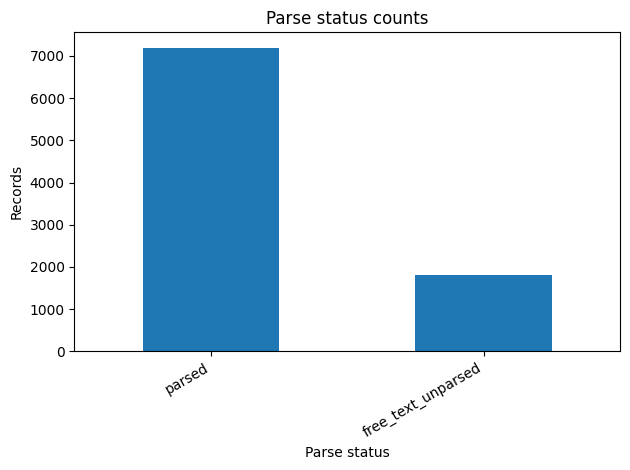

In [5]:
ax = parse_counts.plot(kind="bar", x="parse_status", y="count", legend=False)
ax.set_title("Parse status counts")
ax.set_xlabel("Parse status")
ax.set_ylabel("Records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [6]:
# Parse status by prompt_id
parse_by_prompt = pd.crosstab(parsed["prompt_id"], parsed["parse_status"], margins=True)
display(parse_by_prompt)

parse_status,free_text_unparsed,parsed,All
prompt_id,,,
p_direct_schema_v1,0,1800,1800
p_direct_schema_v2_abstention,0,1800,1800
p_naive_v1,1800,0,1800
p_structured_roles_v1,0,1800,1800
p_structured_roles_v2_abstention,0,1800,1800
All,1800,7200,9000


In [7]:
# Parse rate by provider/model/prompt
parse_summary = summarize_group(parsed, ["provider", "model_id", "prompt_id"])
display(display_percent_table(parse_summary, [
    "parse_rate", "schema_present_accuracy", "primary_schema_accuracy",
    "literal_metaphorical_accuracy", "control_accuracy", "control_false_positive_schema_rate",
    "non_control_lm_accuracy"
]))

,provider,model_id,prompt_id,n,parsed_n,parse_rate,schema_present_accuracy,primary_schema_accuracy,literal_metaphorical_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy
0,anthropic,claude_sonnet_4_6,p_direct_schema_v1,600,600,100.0%,68.5%,61.0%,68.5%,4.5%,95.5%,100.0%
1,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,600,600,100.0%,92.2%,85.8%,92.2%,76.3%,23.7%,100.0%
2,anthropic,claude_sonnet_4_6,p_naive_v1,600,0,0.0%,NA,NA,NA,NA,NA,NA
3,anthropic,claude_sonnet_4_6,p_structured_roles_v1,600,600,100.0%,91.2%,80.7%,91.2%,73.2%,26.8%,100.0%
4,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,600,600,100.0%,90.8%,81.3%,90.3%,72.2%,27.8%,99.3%
5,google,gemini_2_5_flash,p_direct_schema_v1,600,600,100.0%,76.8%,70.5%,76.8%,29.8%,70.2%,100.0%
6,google,gemini_2_5_flash,p_direct_schema_v2_abstention,600,600,100.0%,87.2%,81.2%,87.2%,61.1%,38.9%,100.0%
7,google,gemini_2_5_flash,p_naive_v1,600,0,0.0%,NA,NA,NA,NA,NA,NA
8,google,gemini_2_5_flash,p_structured_roles_v1,600,600,100.0%,82.7%,72.8%,82.7%,47.5%,52.5%,100.0%
9,google,gemini_2_5_flash,p_structured_roles_v2_abstention,600,600,100.0%,88.5%,80.2%,88.5%,65.2%,34.8%,100.0%


In [8]:
# Expected parse behaviour:
# naive -> free_text_unparsed
# direct_schema / structured_role_based -> parsed unless malformed JSON
expected = parsed.copy()
expected["expected_parse_status"] = np.where(expected["prompt_family"].eq("naive"), "free_text_unparsed", "parsed")
expected["parse_matches_prompt_design"] = expected["parse_status"].eq(expected["expected_parse_status"])

expected_summary = (
    expected.groupby(["prompt_id", "prompt_family", "prompt_generation"])
    .agg(n=("run_key", "count"), parse_design_match_rate=("parse_matches_prompt_design", "mean"))
    .reset_index()
)
display(display_percent_table(expected_summary, ["parse_design_match_rate"]))

,prompt_id,prompt_family,prompt_generation,n,parse_design_match_rate
0,p_direct_schema_v1,direct_schema,v1,1800,100.0%
1,p_direct_schema_v2_abstention,direct_schema,v2_abstention,1800,100.0%
2,p_naive_v1,naive,v1,1800,100.0%
3,p_structured_roles_v1,structured_role_based,v1,1800,100.0%
4,p_structured_roles_v2_abstention,structured_role_based,v2_abstention,1800,100.0%


In [9]:
# Inspect parse errors. These are analytically meaningful and should not trigger API reruns automatically.
errors = parsed[parsed["parse_status"].eq("parse_error")].copy()
print(f"Parse errors: {len(errors)}")

if not errors.empty:
    display(errors[[
        "run_key", "provider", "model_id", "prompt_id", "sentence_id",
        "sentence_type", "parse_error"
    ]].head(30))

Parse errors: 0


In [10]:
# Coverage estimate: observed jobs by model x prompt x sentence_type.
coverage = (
    parsed.groupby(["provider", "model_id", "prompt_id", "sentence_type"])
    .size()
    .reset_index(name="observed_records")
    .sort_values(["provider", "model_id", "prompt_id", "sentence_type"])
)
display(coverage)

,provider,model_id,prompt_id,sentence_type,observed_records
0,anthropic,claude_sonnet_4_6,p_direct_schema_v1,control_weak_schema,198
1,anthropic,claude_sonnet_4_6,p_direct_schema_v1,literal_spatial,201
2,anthropic,claude_sonnet_4_6,p_direct_schema_v1,metaphorical_spatial,201
3,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,control_weak_schema,198
4,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,literal_spatial,201
5,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,metaphorical_spatial,201
6,anthropic,claude_sonnet_4_6,p_naive_v1,control_weak_schema,198
7,anthropic,claude_sonnet_4_6,p_naive_v1,literal_spatial,201
8,anthropic,claude_sonnet_4_6,p_naive_v1,metaphorical_spatial,201
9,anthropic,claude_sonnet_4_6,p_structured_roles_v1,control_weak_schema,198


## Interpretation notes

- The naïve prompt is expected to produce `free_text_unparsed`; that is not a failure.
- v1 and v2 structured prompts should normally parse as JSON.
- Parse errors should be preserved, inspected, and reported separately from annotation accuracy.
- If v2 prompts have lower parse-error rates, that is itself evidence that prompt design improved not only classification but output reliability.